# Driver Fatigue Detection — CNN + SVM Pipeline

End-to-end pipeline: **data loading → CNN training → SVM training → evaluation → real-time inference**.

| Stage | Details |
|---|---|
| Input | 64x64 RGB images |
| Face detection | OpenCV Haar Cascade |
| Feature extraction | 3-block CNN — 2304-dim `flatten` output |
| Classification | Linear SVM on CNN embeddings |
| Classes | 0 = Awake, 1 = Drowsy |

In [1]:
# =============================================================================
# IMPORTS & CONFIGURATION  —  Run this cell first.
# =============================================================================
import os
import random
from pathlib import Path

import cv2
import joblib
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, roc_auc_score, RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Conv2D, Dense, Dropout, Flatten, MaxPooling2D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2

# -- Reproducibility ----------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -- Paths --------------------------------------------------------------------
# Works whether Jupyter is launched from the project root or notebooks/ folder.
_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == 'notebooks' else _cwd

AWAKE_DIR  = PROJECT_ROOT / 'data' / 'awake'   # awake driver images go here
DROWSY_DIR = PROJECT_ROOT / 'data' / 'drowsy'  # drowsy driver images go here
MODELS_DIR = PROJECT_ROOT / 'models'
ASSETS_DIR = PROJECT_ROOT / 'assets'

MODELS_DIR.mkdir(exist_ok=True)
ASSETS_DIR.mkdir(exist_ok=True)

# -- Hyper-parameters ---------------------------------------------------------
IMAGE_SIZE = (64, 64)
BATCH_SIZE = 32
EPOCHS     = 30

print('Project root :', PROJECT_ROOT)
print('Awake dir    :', AWAKE_DIR)
print('Drowsy dir   :', DROWSY_DIR)


Project root : c:\Users\USER\Desktop\driver-fatigue-detection
Awake dir    : c:\Users\USER\Desktop\driver-fatigue-detection\data\awake
Drowsy dir   : c:\Users\USER\Desktop\driver-fatigue-detection\data\drowsy


## 1. Data Loading & Exploration

Awake  images : 19445
Drowsy images : 22348
Total         : 41793

Train : 29255 samples
Val   : 6269 samples
Test  : 6269 samples  (held out, not used during training)


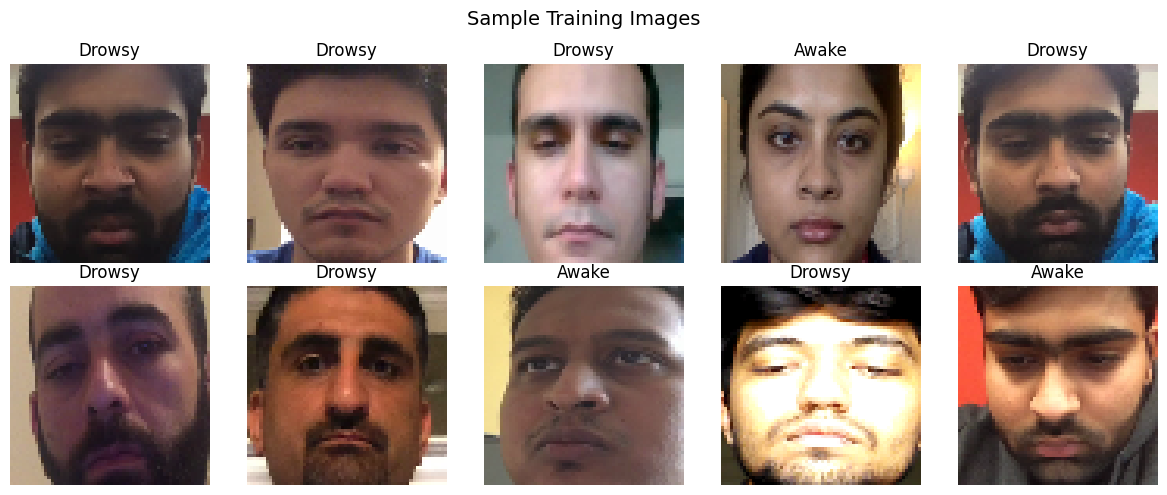

In [2]:
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

def load_images_from_folder(folder: Path, label: int):
    """Load, resize, and label all images in folder."""
    images, labels = [], []
    for fname in sorted(os.listdir(folder)):
        if Path(fname).suffix.lower() not in VALID_EXTS:
            continue
        img = cv2.imread(str(folder / fname))
        if img is not None:
            images.append(cv2.resize(img, IMAGE_SIZE))
            labels.append(label)
    return images, labels


awake_imgs,  awake_lbls  = load_images_from_folder(AWAKE_DIR,  label=0)
drowsy_imgs, drowsy_lbls = load_images_from_folder(DROWSY_DIR, label=1)

print(f"Awake  images : {len(awake_imgs)}")
print(f"Drowsy images : {len(drowsy_imgs)}")
print(f"Total         : {len(awake_imgs) + len(drowsy_imgs)}")

# -- Combine & normalise ------------------------------------------------------
X = np.array(awake_imgs + drowsy_imgs, dtype=np.float32) / 255.0
y = np.array(awake_lbls + drowsy_lbls)

# -- Stratified 70 / 15 / 15 split -------------------------------------------
# stratify= ensures both classes are proportionally represented in every split.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"\nTrain : {X_train.shape[0]} samples")
print(f"Val   : {X_val.shape[0]} samples")
print(f"Test  : {X_test.shape[0]} samples  (held out, not used during training)")

# -- Sample image grid --------------------------------------------------------
class_names = {0: "Awake", 1: "Drowsy"}
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(cv2.cvtColor((X_train[i] * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
    ax.set_title(class_names[int(y_train[i])])
    ax.axis("off")
plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.show()


## 2. CNN Architecture & Training

All layers are given **explicit names** so the feature extractor can reference them
by name (not by fragile integer index), which eliminates the dimension-mismatch bug.

In [3]:
# -- Data augmentation --------------------------------------------------------
datagen = ImageDataGenerator(
    rotation_range=20, width_shift_range=0.2, height_shift_range=0.2,
    shear_range=0.2, zoom_range=0.2, horizontal_flip=True, fill_mode="nearest"
)
datagen.fit(X_train)

# -- Model (Functional API) ---------------------------------------------------
# Using the Functional API guarantees .input is always defined,
# which is required by Keras 3 / TF 2.16+ when creating sub-models.
_inp = tf.keras.Input(shape=(*IMAGE_SIZE, 3), name="input_layer")
_x   = Conv2D(16, (3,3), activation="relu", kernel_regularizer=l2(0.001), name="conv1")(_inp)
_x   = MaxPooling2D((2,2), name="pool1")(_x)
_x   = Dropout(0.25, name="drop1")(_x)
_x   = Conv2D(32, (3,3), activation="relu", kernel_regularizer=l2(0.001), name="conv2")(_x)
_x   = MaxPooling2D((2,2), name="pool2")(_x)
_x   = Dropout(0.25, name="drop2")(_x)
_x   = Conv2D(64, (3,3), activation="relu", kernel_regularizer=l2(0.001), name="conv3")(_x)
_x   = MaxPooling2D((2,2), name="pool3")(_x)
_x   = Dropout(0.50, name="drop3")(_x)
_x   = Flatten(name="flatten")(_x)
_fc1 = Dense(128, activation="relu", kernel_regularizer=l2(0.001), name="fc1")(_x)
_x   = Dropout(0.50, name="drop4")(_fc1)
_out = Dense(1, activation="sigmoid", name="output")(_x)
cnn_model = Model(inputs=_inp, outputs=_out, name="fatigue_cnn")

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy", metrics=["accuracy"]
)
cnn_model.summary()

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3, min_lr=1e-6, verbose=1),
]
history = cnn_model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED),
    epochs=EPOCHS, validation_data=(X_val, y_val), callbacks=callbacks, verbose=1
)

cnn_model.save(MODELS_DIR / "cnn_model.keras")
print("CNN model saved to", MODELS_DIR / "cnn_model.keras")


Model: "fatigue_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop4 (Dropout)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 318,753 (1.22 MB)

 Trainable params: 318,753 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
915/915 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - accuracy: 0.5706 - loss: 0.8750 - val_accuracy: 0.6778 - val_loss: 0.7702 - learning_rate: 1.0000e-04
Epoch 2/30
915/915 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - accuracy: 0.6851 - loss: 0.7161 - val_accuracy: 0.7354 - val_loss: 0.6340 - learning_rate: 1.0000e-04
Epoch 3/30
915/915 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - accuracy: 0.7302 - loss: 0.6400 - val_accuracy: 0.7808 - val_loss: 0.5764 - learning_rate: 1.0000e-04
Epoch 4/30
915/915 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - accuracy: 0.7493 - loss: 0.5988 - val_accuracy: 0.8260 - val_loss: 0.5191 - learning_rate: 1.0000e-04
Epoch 5/30
915/915 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - accuracy: 0.7684 - loss: 0.5643 - val_accuracy: 0.8445 - val_loss: 0.4734 - learning_rate: 1.0000e-04
Epoch 6/30
915/915 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - accuracy: 0.7943 - loss: 0.5273 - val_accuracy: 0.8544 - val_loss: 0.4318 - learning_rate: 1.0000e-04
Epoch 7/30
915/915 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/ste

## 3. Training History

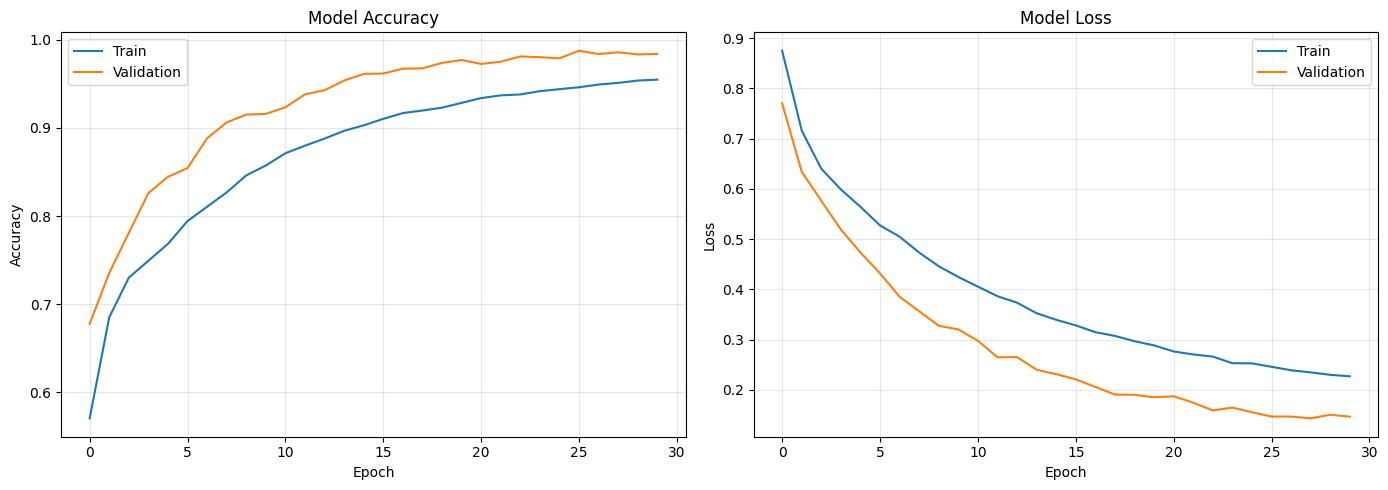

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history["accuracy"],     label="Train")
ax1.plot(history.history["val_accuracy"], label="Validation")
ax1.set_title("Model Accuracy"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history.history["loss"],     label="Train")
ax2.plot(history.history["val_loss"], label="Validation")
ax2.set_title("Model Loss"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ASSETS_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Feature Extraction & SVM Training

A **feature extractor** is created by slicing the CNN at the `flatten` layer (2304-dim output).
These spatial feature maps — richer than the bottlenecked `fc1` embeddings (128-dim) — are fed into the SVM.

Referencing the layer by **name** guarantees the same feature dimensions
are used in SVM training, evaluation, and real-time inference.

In [5]:
# -- Feature extractor: CNN input -> flatten output (2304-dim) ---------------
# _inp was defined in the CNN cell above (Functional API keeps it in scope).
# Using the flatten layer gives the SVM richer spatial features than fc1 (128-dim).
_flatten_out = cnn_model.get_layer("flatten").output
feature_extractor = Model(inputs=_inp, outputs=_flatten_out, name="feature_extractor")
print(f"Feature vector size: {feature_extractor.output_shape[1]}")

X_train_feat = feature_extractor.predict(X_train, batch_size=BATCH_SIZE, verbose=0)
X_val_feat   = feature_extractor.predict(X_val,   batch_size=BATCH_SIZE, verbose=0)
X_test_feat  = feature_extractor.predict(X_test,  batch_size=BATCH_SIZE, verbose=0)

print(f"Train features : {X_train_feat.shape}")
print(f"Val   features : {X_val_feat.shape}")
print(f"Test  features : {X_test_feat.shape}")


Feature vector size: 2304
Train features : (29255, 2304)
Val   features : (6269, 2304)
Test  features : (6269, 2304)


In [6]:
# -- SVM training -------------------------------------------------------------
svm_model = SVC(kernel="linear", probability=True, random_state=SEED)
svm_model.fit(X_train_feat, y_train)

val_acc = accuracy_score(y_val, svm_model.predict(X_val_feat))
print(f"SVM Validation Accuracy: {val_acc * 100:.2f}%")

joblib.dump(svm_model, MODELS_DIR / "svm_model.pkl")
print("SVM model saved to", MODELS_DIR / "svm_model.pkl")


SVM Validation Accuracy: 99.97%
SVM model saved to c:\Users\USER\Desktop\driver-fatigue-detection\models\svm_model.pkl


## 5. Model Evaluation on Held-Out Test Set

All metrics use the **test set**, which was never seen during training or validation.
This gives an unbiased estimate of real-world performance.

CNN  --  Test Set Performance
Accuracy : 98.87%
Precision: 99.01%
Recall   : 98.87%
F1 Score : 98.94%
ROC-AUC  : 0.9996


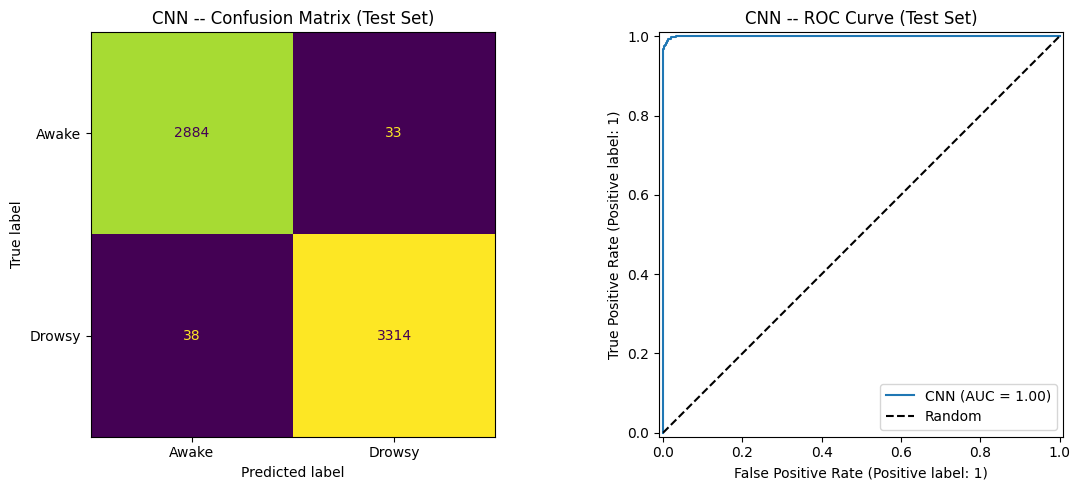

In [7]:
# -- CNN evaluation on test set -----------------------------------------------
y_prob_cnn = cnn_model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).flatten()
y_pred_cnn = (y_prob_cnn >= 0.5).astype(int)

print("=" * 42)
print("CNN  --  Test Set Performance")
print("=" * 42)
print(f"Accuracy : {accuracy_score(y_test, y_pred_cnn)  * 100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_cnn) * 100:.2f}%")
print(f"Recall   : {recall_score(y_test, y_pred_cnn)    * 100:.2f}%")
print(f"F1 Score : {f1_score(y_test, y_pred_cnn)        * 100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_cnn):.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_cnn),
    display_labels=["Awake", "Drowsy"]).plot(ax=ax1, colorbar=False)
ax1.set_title("CNN -- Confusion Matrix (Test Set)")

RocCurveDisplay.from_predictions(y_test, y_prob_cnn, ax=ax2, name="CNN")
ax2.plot([0, 1], [0, 1], "k--", label="Random")
ax2.set_title("CNN -- ROC Curve (Test Set)"); ax2.legend()

plt.tight_layout()
plt.savefig(ASSETS_DIR / "cnn_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()


CNN + SVM  --  Test Set Performance
Accuracy : 99.98%
Precision: 100.00%
Recall   : 99.97%
F1 Score : 99.99%
ROC-AUC  : 1.0000


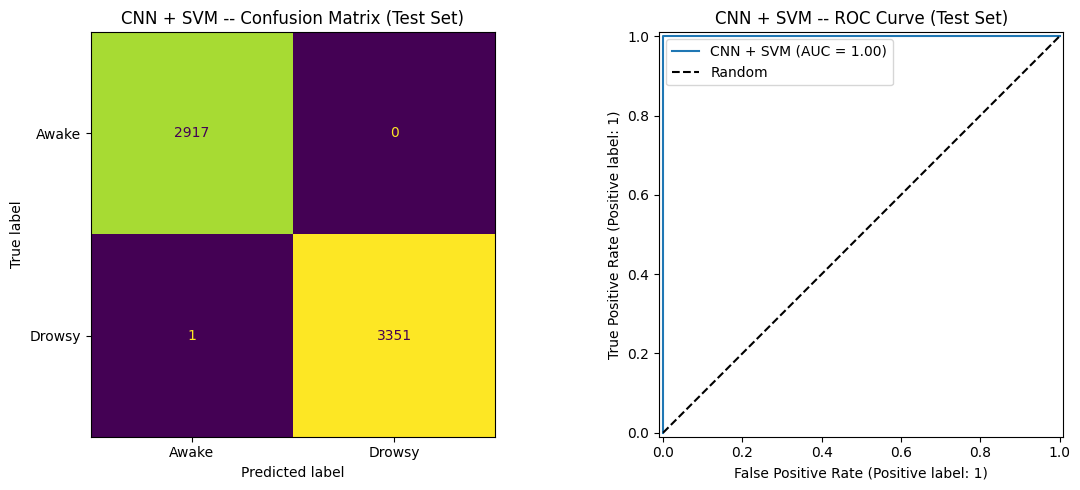

In [8]:
# -- CNN + SVM evaluation on test set -----------------------------------------
y_pred_svm = svm_model.predict(X_test_feat)
y_prob_svm = svm_model.predict_proba(X_test_feat)[:, 1]

print("=" * 42)
print("CNN + SVM  --  Test Set Performance")
print("=" * 42)
print(f"Accuracy : {accuracy_score(y_test, y_pred_svm)  * 100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_svm) * 100:.2f}%")
print(f"Recall   : {recall_score(y_test, y_pred_svm)    * 100:.2f}%")
print(f"F1 Score : {f1_score(y_test, y_pred_svm)        * 100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_svm):.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_svm),
    display_labels=["Awake", "Drowsy"]).plot(ax=ax1, colorbar=False)
ax1.set_title("CNN + SVM -- Confusion Matrix (Test Set)")

RocCurveDisplay.from_predictions(y_test, y_prob_svm, ax=ax2, name="CNN + SVM")
ax2.plot([0, 1], [0, 1], "k--", label="Random")
ax2.set_title("CNN + SVM -- ROC Curve (Test Set)"); ax2.legend()

plt.tight_layout()
plt.savefig(ASSETS_DIR / "svm_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Real-Time Inference

Loads both models from disk and runs live detection on webcam input.

- **Green box** = Awake    **Red box** = Drowsy
- Press **Q** to quit.

> This cell is self-contained: it reloads models from disk and can be run
> independently without re-executing the training cells.

In [ ]:
from IPython.display import Image as IPyImage, display, clear_output

# -- Load models ----------------------------------------------------------
_cnn = tf.keras.models.load_model(MODELS_DIR / "cnn_model.keras")
_feat_extractor = Model(
    inputs=_cnn.input,
    outputs=_cnn.get_layer("flatten").output
)
_svm = joblib.load(MODELS_DIR / "svm_model.pkl")
print(f"Extractor dims : {_feat_extractor.output_shape[1]}")
print(f"SVM expects    : {_svm.n_features_in_}")
assert _feat_extractor.output_shape[1] == _svm.n_features_in_, "Mismatch - re-run Section 4"

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

def _preprocess(face_img):
    return np.expand_dims(
        cv2.resize(face_img, IMAGE_SIZE).astype(np.float32) / 255.0, axis=0
    )

# -- Webcam loop (click Stop / interrupt kernel to quit) ------------------
cap = cv2.VideoCapture(0)
print("Webcam running... click the Stop button to quit.")

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(
            gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
        )

        for (fx, fy, fw, fh) in faces:
            feat  = _feat_extractor.predict(_preprocess(frame[fy:fy+fh, fx:fx+fw]), verbose=0)
            pred  = _svm.predict(feat)[0]
            prob  = _svm.predict_proba(feat)[0]
            label = "Awake" if pred == 0 else "Drowsy"
            conf  = prob[int(pred)]
            col   = (0, 255, 0) if pred == 0 else (0, 0, 255)
            cv2.rectangle(frame, (fx, fy), (fx+fw, fy+fh), col, 2)
            cv2.putText(frame, f"{label}: {conf:.2f}",
                        (fx, fy-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, col, 2)

        # Encode to JPEG and display inline - no cv2.imshow needed
        _, buf = cv2.imencode(".jpg", frame)
        clear_output(wait=True)
        display(IPyImage(data=buf.tobytes()))

except KeyboardInterrupt:
    pass
finally:
    cap.release()
    print("Done.")
